# Best Candidate Selection

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df_all = root_pandas.read_root('exp16_17_e_idglobal_all_cut_MVA2_1_applied.root', key='B0')

Welcome to JupyROOT 6.24/00


In [2]:
df_bestSelected=df_all.loc[df_all.groupby(['__experiment__','__run__','__event__','__production__']).B_D_ReChi2.idxmin()]

In [3]:
# Signal components
sig_D_e_nu=df_bestSelected.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<16 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
sig_D_tau_nu=df_bestSelected.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
sig_Dst_e_nu=df_bestSelected.query('DecayMode=="sig_Dst_e_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
sig_Dst_tau_nu=df_bestSelected.query('DecayMode=="sig_Dst_tau_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
all_Dstst_e_nu=df_bestSelected.query('DecayMode=="all_Dstst_e_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
all_Dstst_tau_nu=df_bestSelected.query('DecayMode=="all_Dstst_tau_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()

#sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<16').copy()
#sig_Dst_mu_nu=df_bestSelected.query('DecayMode=="sig_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
#all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_combinatorial = df_bestSelected.query('B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_sigOtherBDTaudecay = df_bestSelected.query('(DecayMode=="bkg" or DecayMode=="sig_D_mu_nu" or DecayMode=="sig_Dst_mu_nu" or DecayMode=="all_Dstst_mu_nu") and \
B0_mcPDG!=300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_recoFakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()

bkg_others = pandas.concat([df_bestSelected,
                           sig_D_e_nu,
                           sig_D_tau_nu,
                           sig_Dst_e_nu,
                           sig_Dst_tau_nu,
                           all_Dstst_e_nu,
                           all_Dstst_tau_nu,
                           bkg_fakeD,
                           bkg_combinatorial,
                           bkg_sigOtherBDTaudecay,
                           bkg_recoFakeTracksClusters,
                           bkg_continuum]).drop_duplicates(keep=False)
# Weird! the bkg_others contains some events with
# correct sig decay hash chain and correct B0_mcPDG, D_mcPDG, e_genMotherPDG,
# but with 128< B0_mcErrors < 256 (misID)

In [3]:
# Signal components
sig_D_e_nu=df_bestSelected.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<16 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
sig_D_tau_nu=df_bestSelected.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
sig_Dst_e_nu=df_bestSelected.query('DecayMode=="sig_Dst_e_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
sig_Dst_tau_nu=df_bestSelected.query('DecayMode=="sig_Dst_tau_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
all_Dstst_e_nu=df_bestSelected.query('DecayMode=="all_Dstst_e_nu" and abs(D_mcPDG)==411 and \
((B0_mcErrors<64 and abs(e_genMotherPDG)==511) or (B0_mcErrors<512 and abs(e_genMotherPDG)==521))').copy()
all_Dstst_tau_nu=df_bestSelected.query('DecayMode=="all_Dstst_tau_nu" and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15 and \
((B0_mcErrors<64 and abs(B0_mcPDG)==511) or (B0_mcErrors<512 and abs(B0_mcPDG)==521))').copy()

#sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<16').copy()
#sig_Dst_mu_nu=df_bestSelected.query('DecayMode=="sig_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
#all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
bkg_fakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_fakeDTC = pandas.concat([bkg_fakeD, bkg_fakeTracksClusters])

bkg_combinatorial = df_bestSelected.query('B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
bkg_sigOtherBDTaudecay = df_bestSelected.query('(DecayMode=="bkg" or DecayMode=="sig_D_mu_nu" or DecayMode=="sig_Dst_mu_nu" or DecayMode=="all_Dstst_mu_nu") and \
B0_mcPDG!=300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
bkg_fakeB = pandas.concat([bkg_combinatorial, bkg_sigOtherBDTaudecay])

bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()

bkg_others = pandas.concat([df_bestSelected,
                           sig_D_e_nu,
                           sig_D_tau_nu,
                           sig_Dst_e_nu,
                           sig_Dst_tau_nu,
                           all_Dstst_e_nu,
                           all_Dstst_tau_nu,
                           bkg_fakeDTC,
                           bkg_fakeB,
                           bkg_continuum]).drop_duplicates(keep=False)
# Weird! the bkg_others contains some events with
# correct sig decay hash chain and correct B0_mcPDG, D_mcPDG, e_genMotherPDG,
# but with 128< B0_mcErrors < 256 (misID)


def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

kwarg={'bins':50, 'histtype':'step','lw':2}

    
def plot_projection(cut,variable):
    (counts1, bins1) = np.histogram(sig_D_tau_nu.query(cut)[variable], bins=50)
    (counts2, bins2) = np.histogram(sig_Dst_tau_nu.query(cut)[variable], bins=50)
    factor = 1
    plt.hist(bins1[:-1], bins1, weights=factor*counts1,label=f'D_tau_nu \n{statistics(sig_D_tau_nu.query(cut)[variable])}',alpha=0.6)
    sig_D_e_nu.query(cut)[variable].hist(label=f'D_e_nu \n{statistics(sig_D_e_nu.query(cut)[variable])}',**kwarg)
    
    plt.hist(bins2[:-1], bins2, weights=factor*counts2,label=f'Dst_tau_nu \n{statistics(sig_Dst_tau_nu.query(cut)[variable])}',alpha=0.6,histtype='step',lw=2)
    sig_Dst_e_nu.query(cut)[variable].hist(label=f'Dst_e_nu \n{statistics(sig_Dst_e_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_tau_nu.query(cut)[variable].hist(label=f'all_Dstst_tau_nu \n{statistics(all_Dstst_tau_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_e_nu.query(cut)[variable].hist(label=f'all_Dstst_e_nu \n{statistics(all_Dstst_e_nu.query(cut)[variable])}',**kwarg)
    bkg_fakeDTC.query(cut)[variable].hist(label=f'bkg_fakeD_Tracks_Clusters \n{statistics(bkg_fakeDTC.query(cut)[variable])}',**kwarg)
    bkg_fakeB.query(cut)[variable].hist(label=f'bkg_comb_wrongDecay \n{statistics(bkg_fakeB.query(cut)[variable])}',**kwarg)
    bkg_continuum.query(cut)[variable].hist(label=f'bkg_continuum \n{statistics(bkg_continuum.query(cut)[variable])}',**kwarg)
    bkg_others.query(cut)[variable].hist(label=f'bkg_others \n{statistics(bkg_others.query(cut)[variable])}',**kwarg)
    plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

def plot_q2_efficiency(cut, q2='B0_CMS3_weQ2lnuSimple'):
    sig_D_e_nu_BC=samples['BC'].query('DecayMode=="sig_D_e_nu" and B0_mcErrors<16 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
    sig_D_tau_nu_BC=samples['BC'].query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
    (counts1, bins1) = np.histogram(sig_D_e_nu_BC.query(cut)[q2], bins=15)
    (counts2, bins2) = np.histogram(sig_D_e_nu.query(cut)[q2], bins=bins1)
    
    efficiency = counts2 / counts1
    efficiency_err = efficiency * np.sqrt(1/counts1 + 1/counts2)
    #factor = 1
    #plt.hist(bins1[:-1], bins1, weights=factor*efficiency,label='D_l_nu efficiency in q2',histtype='step')
    bin_centers = (bins1[:-1] + bins1[1:]) /2
    plt.errorbar(x=bin_centers, y=efficiency, yerr=efficiency_err, fmt='ko',label='D_l_nu efficiency in q2')
    plt.legend()
    
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

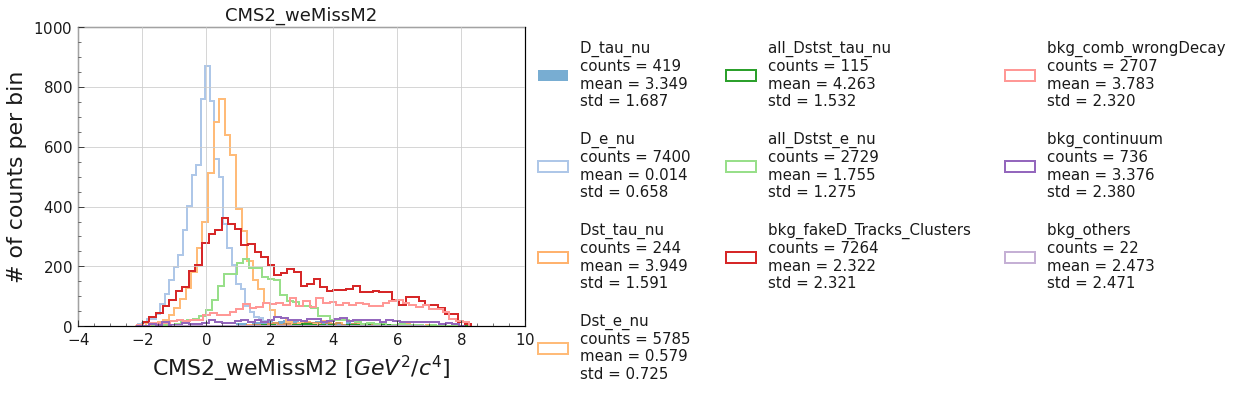

In [4]:
plot_projection('MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)

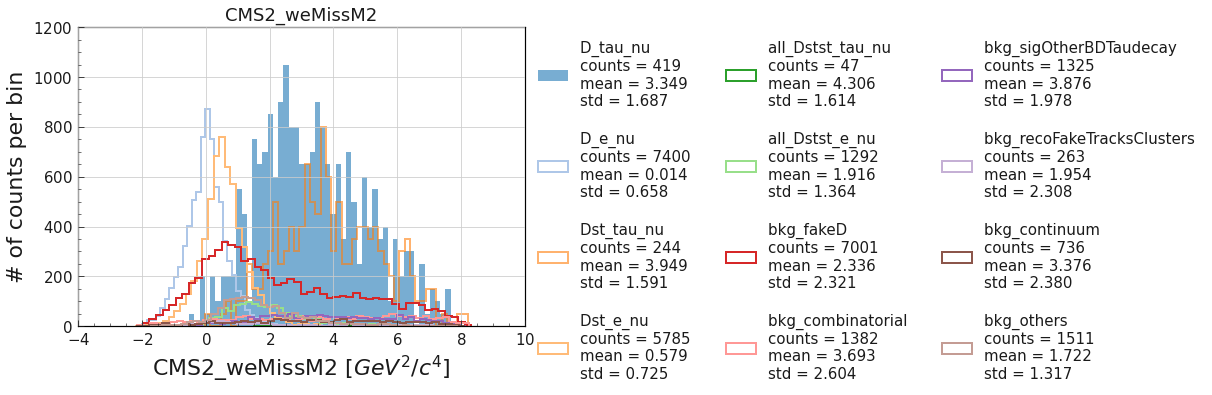

In [5]:
plot_projection('MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)

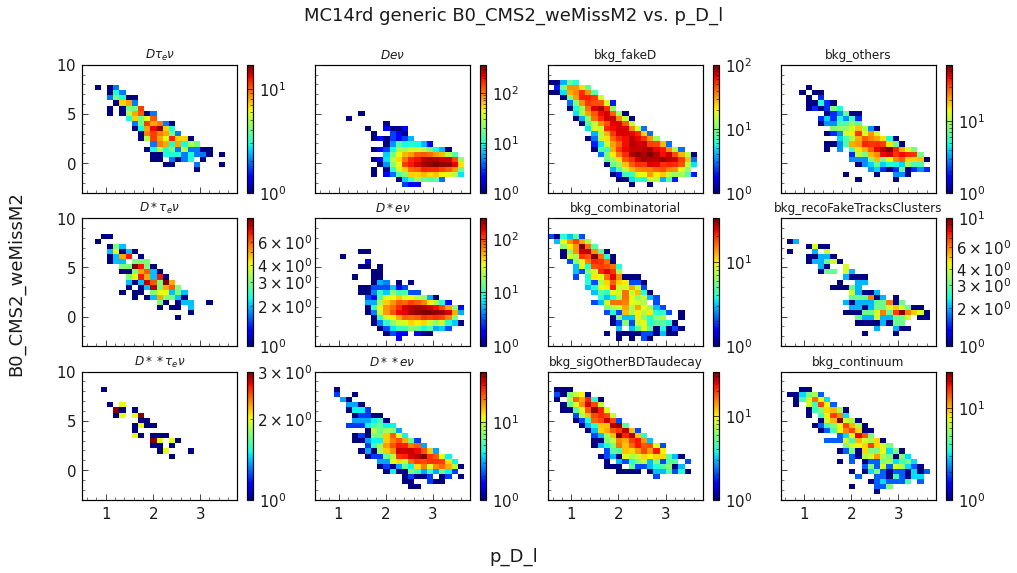

In [6]:
name_list = [r'$D\tau_e\nu$',r'$D*\tau_e\nu$',r'$D**\tau_e\nu$',
             r'$De\nu$',r'$D*e\nu$',r'$D**e\nu$',
             'bkg_fakeD','bkg_combinatorial',
             'bkg_sigOtherBDTaudecay','bkg_others',
             'bkg_recoFakeTracksClusters','bkg_continuum']
df_list = [sig_D_tau_nu,sig_Dst_tau_nu,all_Dstst_tau_nu, 
           sig_D_e_nu,sig_Dst_e_nu,all_Dstst_e_nu, 
           bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
           bkg_others,bkg_recoFakeTracksClusters, bkg_continuum]   
    
    
df_dict = dict(zip(name_list, df_list))

cuts='MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'

variable_y = 'B0_CMS2_weMissM2'
variable_x = 'p_D_l'

n_rows,n_cols = [3,4]
fig,ax=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
fig.suptitle(f'MC14rd generic {variable_y} vs. {variable_x}')
fig.supxlabel(f'{variable_x}')
fig.supylabel(f'{variable_y}',x=0.06)
k=0
for j in range(n_cols):
    for i in range(n_rows):
        counts, xedges, yedges, im = ax[i,j].hist2d(df_dict[name_list[k]].query(cuts)[variable_x],
                                                    df_dict[name_list[k]].query(cuts)[variable_y],
                                                    range=[[0.5,3.8],[-3,10]],bins=25,cmap='jet',
                                                    norm=colors.LogNorm())
        ax[i,j].set_title(name_list[k],fontsize=12)
        fig.colorbar(im,ax=ax[i,j])
        k+=1

#plt.xlabel('$p_{D}+p_{l}\ [GeV/c]$')
#plt.ylabel('$M_{miss}^2\ [GeV^2/c^4]$')

In [ ]:
name_list = [r'$D\tau_e\nu$',r'$D*\tau_e\nu$',r'$D**\tau_e\nu$',
             r'$De\nu$',r'$D*e\nu$',r'$D**e\nu$',
             'bkg_fakeD','bkg_combinatorial',
             'bkg_sigOtherBDTaudecay','bkg_recoWrongSideB',
             'bkg_recoFakeTracksClusters','bkg_continuum']
df_list = [sig_D_tau_nu,all_Dst_tau_nu,all_Dstst_tau_nu, 
           sig_D_e_nu,all_Dst_e_nu,all_Dstst_e_nu, 
           bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
           bkg_recoWrongSideB,bkg_recoFakeTracksClusters, bkg_continuum]   
    
    
df_dict = dict(zip(name_list, df_list))

cuts='MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26'

variable_y = 'B0_CMS2_weMissM2'
variable_x = 'p_D_l'

n_rows,n_cols = [3,4]
fig,ax=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
fig.suptitle(f'MC14rd generic {variable_y} vs. {variable_x}')
fig.supxlabel(f'{variable_x}')
fig.supylabel(f'{variable_y}',x=0.06)
k=0
for j in range(n_cols):
    for i in range(n_rows):
        counts, xedges, yedges, im = ax[i,j].hist2d(df_dict[name_list[k]].query(cuts)[variable_x],
                                                    df_dict[name_list[k]].query(cuts)[variable_y],
                                                    range=[[0.5,3.8],[-3,10]],bins=25,cmap='jet',
                                                    norm=colors.LogNorm())
        ax[i,j].set_title(name_list[k],fontsize=12)
        fig.colorbar(im,ax=ax[i,j])
        k+=1

#plt.xlabel('$p_{D}+p_{l}\ [GeV/c]$')
#plt.ylabel('$M_{miss}^2\ [GeV^2/c^4]$')

# Fitting

In [5]:
import pyhf
import mplhep as hep

pyhf.set_backend('numpy','minuit')

In [19]:
### These two are needed only if to update the templates

# bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
# bkg_recoFakeTracksClusters, bkg_continuum, bkg_others
bkg_sample = bkg_fakeD

cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
xedges = np.linspace(0.5, 4, 15)
yedges = np.linspace(-4, 10, 25)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts, xedges, yedges) = np.histogram2d(bkg_sample.query(cut)[variable_x], 
                                          bkg_sample.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T + 0.01

In [20]:
import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC_ROEx1/2d_2channels_workspace.json'
with open(workspace_file, 'r+') as f:
    data = json.load(f)
    # data['channels'][0]['samples'].append({}) # no need after the first time
    data['channels'][0]['samples'][6]['name'] = 'bkg_fakeD'
    data['channels'][0]['samples'][6]['data'] = counts.ravel().tolist()
    # counts.ravel()/.reshape(-1) returns a view, counts.flatten() returns a copy (slower)
    f.seek(0)        # <--- should reset file position to the beginning.
    json.dump(data, f, indent=4)
    f.truncate()     # remove remaining part
#data['channels'][0]['samples'][5]

In [6]:
cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
electron_mode_samples = df_bestSelected.query(cut)
len(electron_mode_samples)

19444

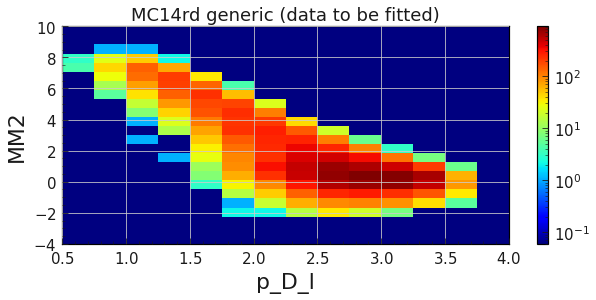

In [7]:
import pyhf
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

pyhf.set_backend('numpy','minuit')

sig_sample = electron_mode_samples

cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
xedges = np.linspace(0.5, 4, 15)
yedges = np.linspace(-4, 10, 25)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts, xedges, yedges) = np.histogram2d(sig_sample.query(cut)[variable_x], 
                                          sig_sample.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T + 0.06
fig,axs=plt.subplots(ncols=1,figsize=(10,4))
X, Y = np.meshgrid(xedges, yedges)
im=axs.pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())
axs.set_title('MC14rd generic (data to be fitted)')
axs.set_ylabel('MM2')
axs.set_xlabel('p_D_l')
#axs.set_aspect('equal')
axs.grid()
fig.colorbar(im)

In [8]:
import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC_ROEx1/2d_2channels_workspace.json'
with open(workspace_file, 'r+') as work_f:
    spec = json.load(work_f)
#    spec['observations'][0]['name'] = 'electron mode'
#    spec['observations'][0]['data'] = counts.ravel().tolist()
    spec_1 = {'channels': spec['channels']}
    model_1 = pyhf.Model(spec_1, poi_name=None)
#model_1.spec
#workspace = pyhf.Workspace(spec)
#workspace

In [ ]:
import ipywidgets as widgets

sliders_norm = {
    f"n{i}" : widgets.FloatSlider(
        1.0,
        min=0.01,
        max=10.0,
        orientation="vertical",
        continuous_update=False,
        description=f"n{i}",
        layout=widgets.Layout(width='45px')
    )
    for i in range(0, 12)
}

def plot(**kwargs):
    parameters = model_1.config.suggested_init()
    
    for k in kwargs:
        i = int(k.replace("n", ""))
        parameters[i] = kwargs[k]
        
    fig, axs = plt.subplots(ncols=2,figsize=(14,4))
    X, Y = np.meshgrid(xedges, yedges)
    im0=axs[0].pcolormesh(X, Y,
                          model_1.expected_data(parameters).reshape(counts.shape),
                          cmap='jet', norm=colors.LogNorm())
    im1=axs[1].pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())

    #axs[0].set_aspect('equal')
    #axs[1].set_aspect('equal')
    axs[0].set_title('initial_template')
    axs[1].set_title('data')
    axs[0].grid()
    axs[1].grid()
    fig.colorbar(im0, ax=axs[0])
    fig.colorbar(im1, ax=axs[1])

    print(
        "Negative Log-Likelihood: "
        f"{- model_1.logpdf(parameters, np.concatenate([counts.flat]))[0]:.3f}"
    )
    
interactive_plot = widgets.interactive_output(plot, dict(sliders_norm))
interactive_plot.layout.height = "300px"

def fit(b):
    parameters = pyhf.infer.mle.fit(np.concatenate([counts.flat]), model_1, return_uncertainties=True)
    # parameters_1bin, correlations_1bin = pyhf.infer.mle.fit(data_1bin, model_1bin, return_uncertainties=True, return_correlations=True)
    sum_event=0
    for k in sliders_norm:
        i = int(k.replace("n", ""))
        sliders_norm[k].value = parameters[i][0]
        template_counts = np.sum(model_1.spec['channels'][0]['samples'][i]['data'])
        component_name = model_1.spec['channels'][0]['samples'][i]['name']
        print(f'\n{component_name} counts:             {parameters[i][0] * template_counts}')
        print(f'{component_name} counts uncertainty: {parameters[i][1] * template_counts}')
        sum_event+= parameters[i][0] * template_counts
    print(f'\nTotal fitted counts: {sum_event}')
    print(f'Total fitted counts uncertainty: 0')
    print(f'Total generated counts: {len(electron_mode_samples)}')
#    print(f'uncertainty: {parameters[0][1]}')
        
button = widgets.Button(description="Fit")
button.on_click(fit)

display(
    button,
    interactive_plot,
    widgets.HBox(
        [widgets.HBox(layout=widgets.Layout(width='45px'))]
        + [sliders_norm[f"n{i}"] for i in range(0, 12)]
    ),
)

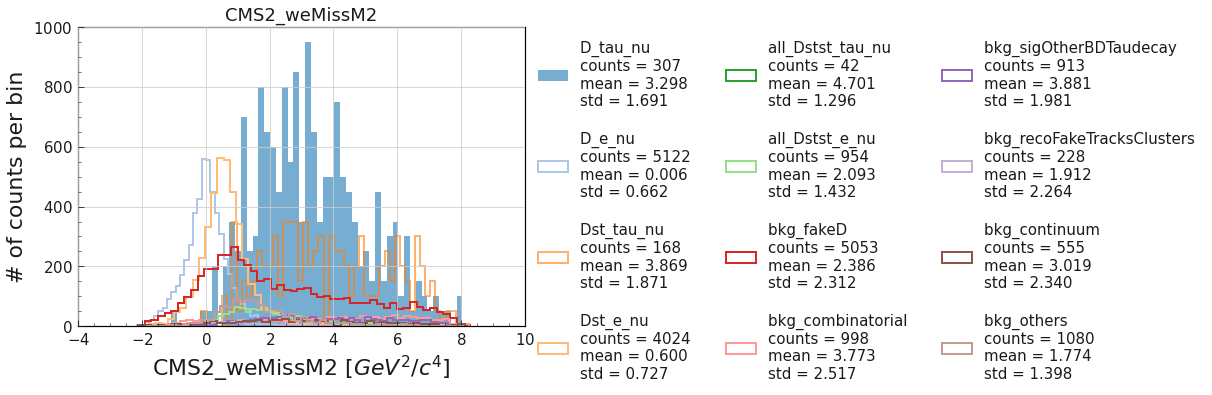

In [25]:
plot_projection('MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)